\begin{equation}
\dot{w_1} = S_{11} w_1 + S_{12} w_2
\end{equation}

\begin{equation}
\varepsilon \dot{w_2} = S_{21} w_1 + S_{22} w_2
\end{equation}

Let's suppose both $w_1$ and $w_2$ are 2nd order systems, so the total signal is a 4th order system. 

[[  -0.1    2.     0.5    0. ]
 [  -2.    -0.1    0.     0.5]
 [ -20.     0.   -10.   100. ]
 [   0.   -20.  -100.   -10. ]]
[-0.1+2.j -0.1-2.j]
[0.5+0.j 0.5+0.j]
[-1.+0.j -1.+0.j]
[-0.5+5.j -0.5-5.j]
[-9.98982695+100.10091028j -9.98982695-100.10091028j
 -0.11017305  +1.89908972j -0.11017305  -1.89908972j]
[1. 0. 0. 0.]
[0. 1. 0. 0.]
[0. 0. 1. 0.]
[0. 0. 0. 1.]
[[2.         1.73205081 1.41421356 1.        ]]


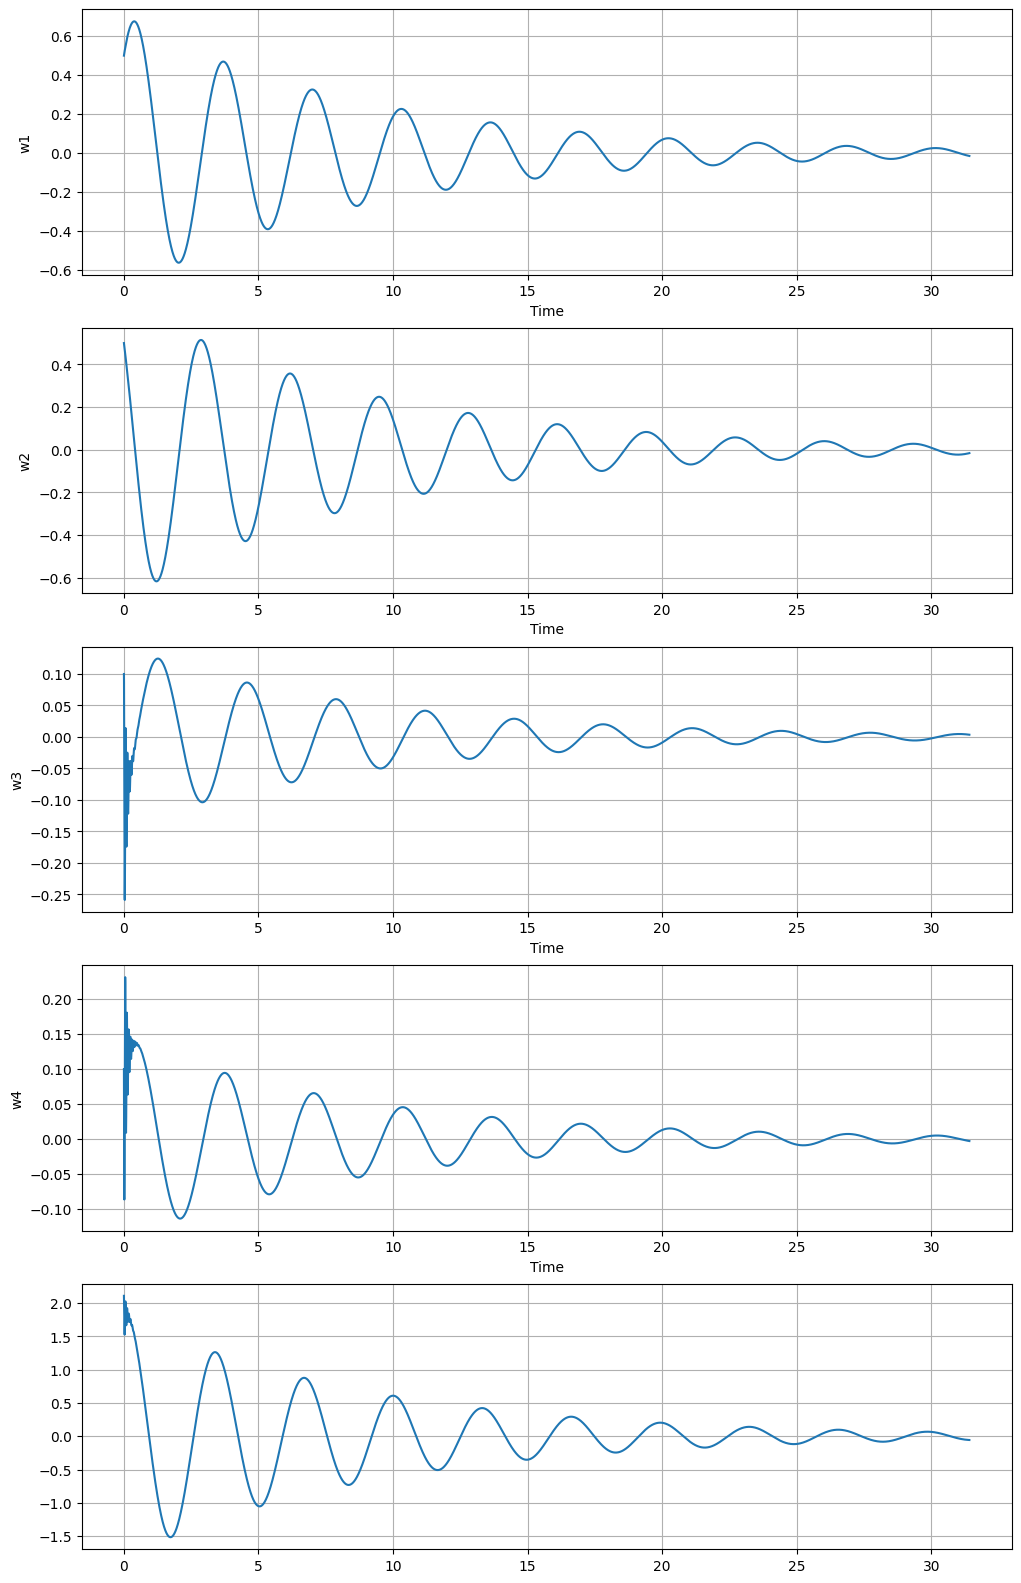

In [266]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la

def signal(t, wg, S11, S12, S21, S22, epsilon):
    w1 = wg[:2]
    w2 = wg[2:]

    dw1 = S11 @ w1 + S12 @ w2
    dw2 = (1/epsilon) * (S21 @ w1 + S22 @ w2)

    return np.concatenate([dw1, dw2])

epsilon = 0.05

S11 = np.array([[-0.1 , 2.0],
                [-2.0, -0.1]])
S12 = np.array([[0.5, 0.],
                [0., 0.5]])

S21 = np.array([[-1., 0.,],
                [0., -1.]])
S22 = np.array([[-0.5, 5.],
                [-5., -0.5]])

Sg = np.block([[S11, S12],
               [(1/epsilon) * S21, (1/epsilon) * S22]])
print(Sg)
print(la.eigvals(S11))
print(la.eigvals(S12))
print(la.eigvals(S21))
print(la.eigvals(S22))

print(la.eigvals(Sg))



t_span = (0., 10.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# initial condition for the signal 
w0 = [0.5, 0.5, 0.1, 0.1]
solw = solve_ivp(
    lambda t, state: signal(t, state,
                            S11 = S11,
                            S12 = S12,
                            S21 = S21, 
                            S22 = S22, 
                            epsilon = epsilon),
    t_span,
    w0, 
    t_eval = t_eval,
    method = 'Radau'
)

plt.figure(figsize = (12,20))
Wg = solw.y #Wg 
for i in range(4):
    Lg = np.zeros(4)
    Lg[i] = 1.0
    plt.subplot(5,1,i+1)
    print(Lg)
    plt.plot(solw.t, (Lg @ Wg).flatten())
    plt.xlabel("Time")
    plt.ylabel("w" + str(i+1))
    plt.grid(True)

Lg = np.array([[(4.0-i)**0.5 for i in range(4)]]) # Lg
print(Lg)
plt.subplot(5,1,5)
plt.plot(solw.t, (Lg@Wg).flatten())
plt.grid(True)
plt.show()

We can see that w3 and w4 have fast smaller, fast oscillations as well as the slow oscillations. The time derivative is faster, as it is divided by a small number epsilon. 
As the signal is the singularly perturbed, we can find the slow manifold. 
Setting $\varepsilon$ to zero, and writing $w_2$ in terms of $w_1$:

\begin{equation}
w_2 = -S_{22} ^{-1} S_{21} w_1
\end{equation}

\begin{equation}
\dot{w_1} = (S_{11}-S_{12} S_{22} ^{-1} S_{21}) w_1
\end{equation}

\begin{equation}
u = (L_{g1} - L_{g2} S_{22} ^ {-1} S_{21}) w_1
\end{equation}

[[2.         1.73205081 1.41421356 1.        ]]
[2.         1.73205081]
[1.41421356 1.        ]


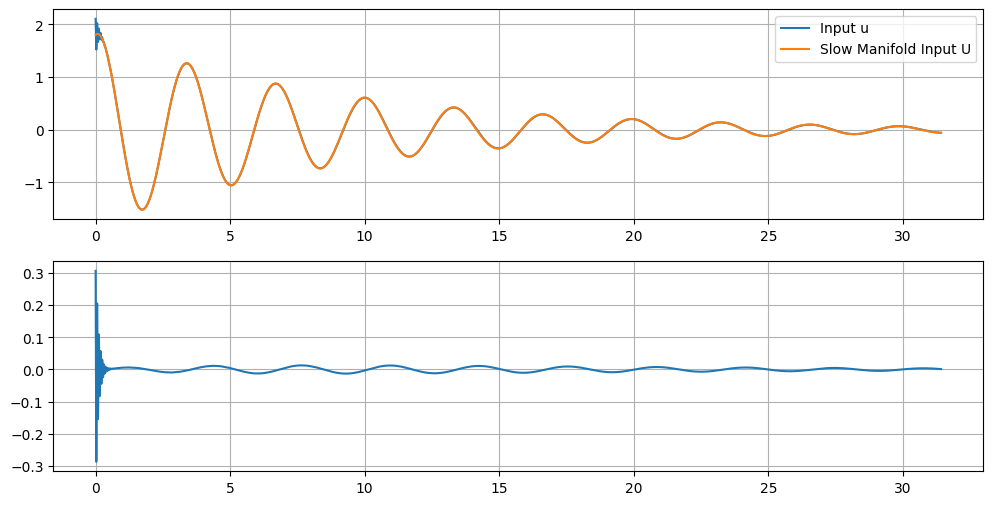

In [267]:
S22inv = np.linalg.inv(S22)

def slow_manifold_signal(t, w, S11, S12, S21, S22):
    inverse = np.linalg.inv(S22)
    dw = (S11 - S12 @ inverse @ S21) @ w
    return dw

solwslow = solve_ivp(
    lambda t, state: slow_manifold_signal(t, state,
                            S11 = S11,
                            S12 = S12,
                            S21 = S21, 
                            S22 = S22),
    t_span,
    w0[:2],  # as we are only concerned with w1
    t_eval = t_eval,
    method = 'Radau'
)

Lg1 = Lg[0][:2]
Lg2 = Lg[0][2:]
w1 = solwslow.y 
print(Lg)
print(Lg1)
print(Lg2)
Uslow = (Lg1 - (Lg2 @ S22inv @ S21)) @ w1

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(solw.t, (Lg@Wg).flatten(), label = "Input u")
plt.plot(solw.t, Uslow.flatten(), label = 'Slow Manifold Input U')
plt.legend()
plt.grid(True)

# The difference between slow manifold and full signal
plt.subplot(2,1,2)
plt.plot(solw.t, ( (Lg@Wg) - Uslow ).flatten())
plt.grid(True)

plt.show()



Remark: Can a system that has noise added to it be modelled as a singularly perturbed system?

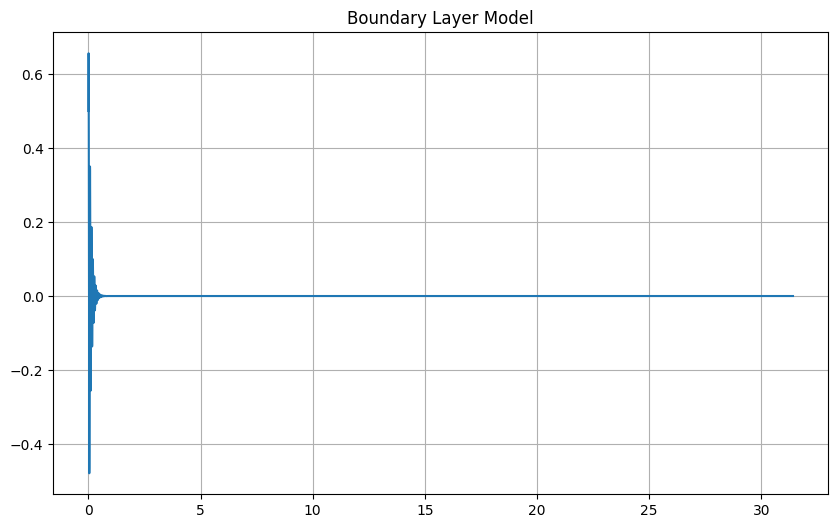

In [268]:
def boundary_layer(t, y, epsilon, S22):
    dy = (1/epsilon) * S22 @ y
    return dy

solboundary = solve_ivp(
    lambda t, state: boundary_layer(t, state, epsilon = epsilon, S22 = S22), 
    t_span,
    w0[:2],  # as we are only concerned with w1
    t_eval = t_eval,
    method = 'Radau'
)

y = solboundary.y
plt.figure(figsize = (10,6))
plt.plot(solboundary.t, (np.array([1.0,0.]) @ y).flatten())
plt.title("Boundary Layer Model")
plt.grid(True)
plt.show()



The boundary layer is t

Let's try simulating a singularly perturbed system. 
\begin{equation}
\dot{x}_1 = x_2 - z_2
\end{equation}

\begin{equation}
\dot{x}_2 = -x_1 - \beta x_2 + \beta z_2 + u
\end{equation}

\begin{equation}
\varepsilon \dot{z}_1 = z_2
\end{equation}

\begin{equation}
\varepsilon \dot{z}_2 = \alpha x_1 - \alpha \beta (z_2 - x_2) - z_1 - \alpha u 
\end{equation}

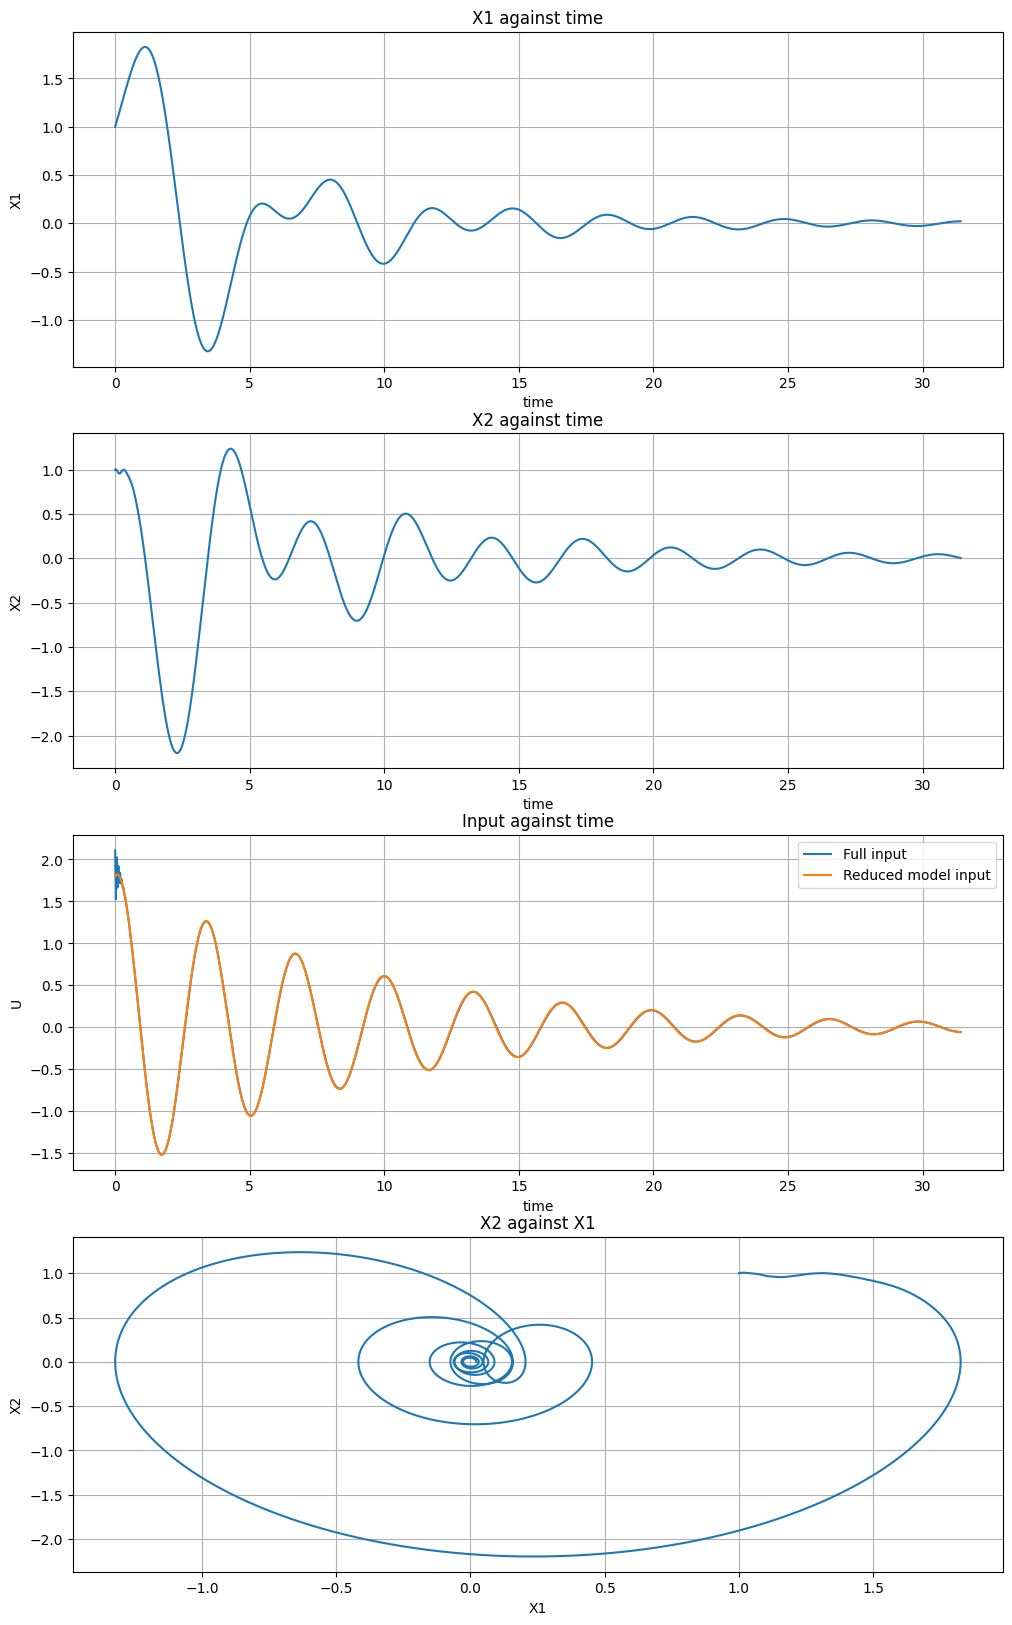

In [269]:
# constants
alpha = 1.0
beta = 0.5
A11 = np.array([[0., 1.],
                [-1., -beta]])
A12 = np.array([[0.,0.],
                [0.,beta]])
A21 = np.array([[0.,0.],
                [alpha, alpha * beta]])
A22 = np.array([[0., 1.0],
                [-1., -alpha * beta]])
B1 = np.array([[0.],
               [1.0]])
B2 = np.array([[0.],
               [-alpha]])

def combined_system(t, state): #x and z are state vectors, u is a single dimensional input
    x = state[:2]
    z = state[2:4]
    w1 = state[4:6]
    w2 = state[6:8]
    u = Lg1 @ w1 + Lg2 @ w2
    dx = A11 @ x + A12 @ z + B1.flatten() * u
    dz = (A21 @ x + A22 @ z + B2.flatten() * u) / epsilon
    dw1 = S11 @ w1 + S12 @ w2
    dw2 = (S21 @ w1 + S22 @ w2) / epsilon
    return np.concatenate( [dx, dz, dw1, dw2])

state0 = [1., 1., 2.,0.5, 0.5, 0.5, 0.1, 0.1]
sol = solve_ivp(combined_system, t_span, state0, t_eval=t_eval, method='Radau')

X = sol.y[:2, :]
Z = sol.y[2:4, :]
W1 = sol.y[4:6, :]
W2 = sol.y[6:8, :]
U = Lg1 @ W1 + Lg2 @ W2


C1 = np.array([[1.0,0.]])
C2 = np.array([[0.,1.]])

Y1 = C1 @ X
Y2 = C2 @ X


plt.figure(figsize = (12,20))

# Output reponse 1
plt.subplot(4,1,1) 
plt.plot( sol.t, Y1.flatten())
plt.title("X1 against time")
plt.grid(True)
plt.xlabel("time")
plt.ylabel("X1")

# Output response 2
plt.subplot(4,1,2)
plt.plot( sol.t, Y2.flatten())
plt.grid(True)
plt.title("X2 against time")
plt.xlabel("time")
plt.ylabel("X2")

# Input
plt.subplot(4,1,3)
plt.plot( sol.t, U.flatten(), label = 'Full input')
plt.plot( sol.t, Uslow.flatten(), label = 'Reduced model input')
plt.grid(True)
plt.legend()
plt.title("Input against time")
plt.xlabel("time")
plt.ylabel("U")


# Phase plane
plt.subplot(4,1,4)
plt.plot( Y1.flatten(), Y2.flatten())
plt.grid(True)
plt.title("X2 against X1")
plt.xlabel("X1")
plt.ylabel("X2")



plt.show()

Moments, numerically.
$\newline$
Let's solve the full Sylvester equation numerically using scipy. 

[-5.00977912+19.23736174j -5.00977912-19.23736174j
 -0.24022088 +0.9769884j  -0.24022088 -0.9769884j ]
[-9.98982695+100.10091028j -9.98982695-100.10091028j
 -0.11017305  +1.89908972j -0.11017305  -1.89908972j]
[[2.         1.73205081 1.41421356 1.        ]]
[[  0.           0.           0.           0.        ]
 [  2.           1.73205081   1.41421356   1.        ]
 [  0.           0.           0.           0.        ]
 [-40.         -34.64101615 -28.28427125 -20.        ]]
[[-0.73988521 -0.64590651  0.00273296 -0.00414679]
 [ 1.31114235 -1.33224389  0.01740718 -0.00818937]
 [-2.41385795 -2.64423088  0.07466057  0.02140078]
 [ 0.20183181 -0.24956542 -0.20468062  0.29649668]]


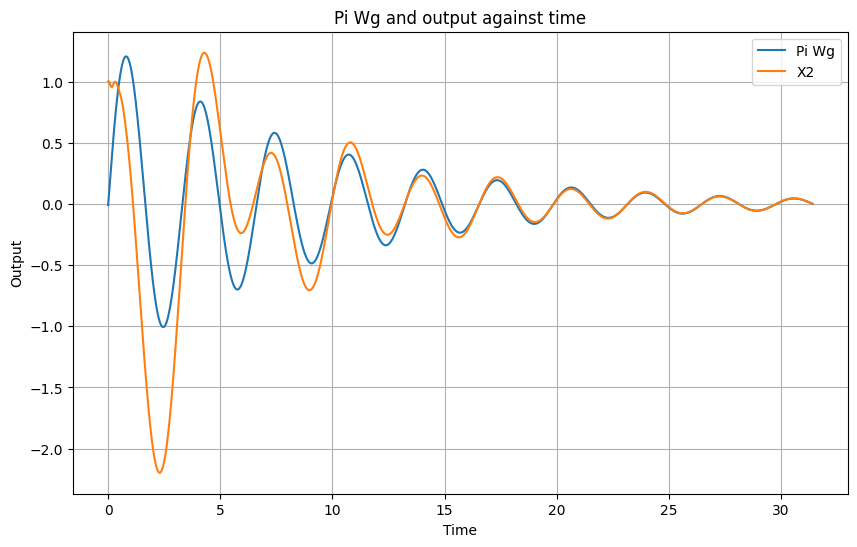

In [270]:
# Block matrix of A11, A12, A21, and A22
A_full = np.block([[A11, A12],
                   [(1/epsilon) * A21, (1/epsilon) * A22]])

print(la.eigvals(A_full))
print(la.eigvals(Sg))
# Block matrix for B
B_full = np.block([[B1], 
                   [(1/epsilon) * B2]])

C = np.array( [[0., 1.0, 0., 0.]])
print(Lg)
print( B_full @ Lg )

# Solving the Sylvester Equation for the full model
Pi = la.solve_sylvester( A_full, -Sg, -B_full @ Lg)
print( Pi )

Piw = Pi @ Wg
YPi = C @ Piw # Output with moments 

# Plotting 
plt.figure(figsize = (10,6))
plt.plot(sol.t, YPi.flatten(), label = "Pi Wg")
plt.plot(sol.t, Y2.flatten(), label  = "X2")
#plt.plot(sol.t, (Y1 - YPi).flatten())
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("Pi Wg and output against time")
plt.legend()
plt.show()


REDUCED MODEL

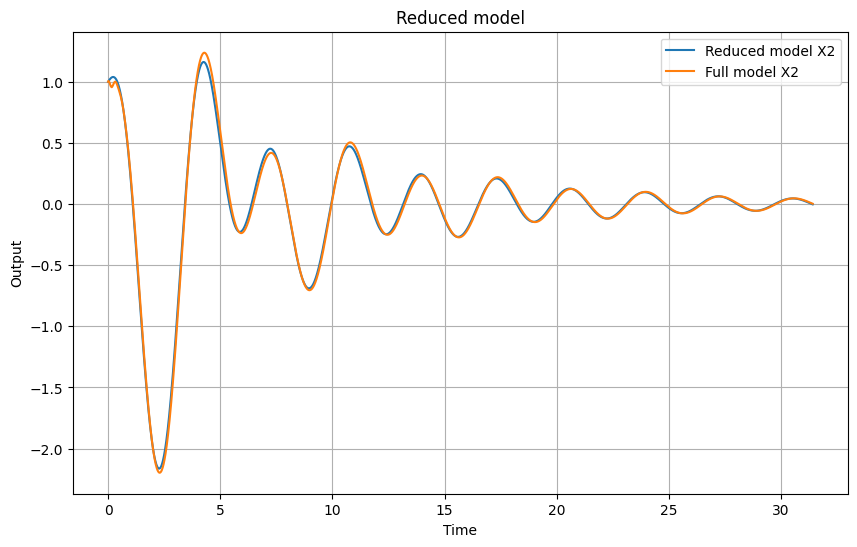

In [271]:
def combined_reduced_model(t, state):
    A22inv = np.linalg.inv(A22)
    x = state[0:2]
    w = state[2:]
    u = (Lg1 - (Lg2 @ S22inv @ S21))  @ w
    dx = (A11 - (A12 @ A22inv @ A21)) @ x + (B1 - (A12 @ A22inv @ B2)).flatten() * u
    dw = (S11 - (S12 @ S22inv @ S21)) @ w
    return np.concatenate([dx, dw])

state_red0 = [1., 1.,0.5, 0.5]
sol_reduced = solve_ivp(
    combined_reduced_model, t_span, state_red0, t_eval=t_eval, method = 'Radau')

X_red= sol_reduced.y[:2, :]
Y_red = C2 @ X_red
Y_red1 = C1 @ X_red


plt.figure( figsize = (10,6))
plt.plot(sol_reduced.t, Y_red.flatten(), label = 'Reduced model X2')
#plt.plot(sol_reduced.t, Y_red1.flatten(), label = "Reduced model X1")
plt.plot(sol.t, Y2.flatten(), label = "Full model X2")
plt.legend()
plt.grid(True)
plt.title("Reduced model")
plt.xlabel("Time")
plt.ylabel("Output")
# plt.xlim(0,5)
# plt.ylim(-1.5,-1.0)
plt.show()